
# Practical 18: YOLO Object Detection (Real‑Time Detection in Practice)


## Why this practical?
After learning CNN fundamentals (Prac 7), deeper nets (Prac 8–11), and transfer learning (Prac 4 & 15),  
we now tackle **real-time object detection** with **YOLO (You Only Look Once)**.  
YOLO is widely used because it's **fast**, **accurate**, and **easy to deploy** on images and video streams.



## Learning Objectives
By the end of this practical, you will be able to:
1. Explain the high-level idea of YOLO and how it differs from image classification.
2. Run inference with a **pretrained YOLO** model on images and video.
3. **Fine‑tune** a YOLO model on a small dataset (e.g., COCO128 or your own data).
4. Evaluate detection performance with **precision, recall, and mAP** (connects to Practical 6).



## 1. What is YOLO? (Quick Concept)
- **Goal:** Detect *what* is in the image **and where** (bounding boxes + class labels).  
- **Single-shot detection:** YOLO predicts bounding boxes and classes in a **single forward pass** (fast!).  
- **Anchor-based vs. anchor-free:** Early YOLO versions used anchors; **YOLOv8** uses an **anchor‑free** head.  
- **Post-processing:** Uses **NMS (Non‑Maximum Suppression)** to remove duplicate boxes.

**Key differences from classification:**  
- Classification outputs *one* label per image.  
- Detection outputs **many** `(box, class, confidence)` per image.

> *Connection:* Your understanding of convolutions (Prac 7), deep backbones (Prac 8–11), and transfer learning (Prac 4 & 15) directly powers YOLO.



## 2. Setup
We'll use the **[Ultralytics YOLO](https://docs.ultralytics.com)** implementation (YOLOv8).  
> If you're in Colab or on your own machine with internet, the following will install the package.


In [ ]:

# If running locally/Colab with internet, uncomment to install:
# !pip -q install ultralytics opencv-python

# (Optional) Check CUDA (GPU) availability to speed up training/inference
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))


PyTorch: 2.5.1
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3060



## 3. Imports


In [ ]:

# Core imports
from pathlib import Path
import os
import matplotlib.pyplot as plt

# YOLO (Ultralytics) — if not installed, run the pip cell above
try:
    from ultralytics import YOLO
    ULTRALYTICS_AVAILABLE = True
except Exception as e:
    ULTRALYTICS_AVAILABLE = False
    print("Ultralytics not installed. Please run the installation cell above.")

# For image/video handling
import cv2  # from opencv-python



## 4. Quickstart: Pretrained YOLO Inference on Images
We'll load a **small pretrained model** (`yolov8n.pt`) and run prediction on a few images.

- If you have internet, YOLO will **download** sample images (e.g., `bus.jpg`) automatically when provided as a URL.  
- **Offline option:** Put some `.jpg` files in `data/samples/` and run on that folder.


In [ ]:

# Create a samples folder for your own test images (optional, for offline use)
Path("data/samples").mkdir(parents=True, exist_ok=True)

if not ULTRALYTICS_AVAILABLE:
    raise SystemExit("Please install ultralytics to continue.")

# Load a small, fast pretrained model (YOLOv8 Nano)
model = YOLO('yolov8n.pt')  # This will download weights if not present

# --- Option A: Use URL or built-in demo images (requires internet) ---
results = model.predict(source='https://ultralytics.com/images/bus.jpg', imgsz=640, conf=0.25, save=True)

# --- Option B: Use your local images in data/samples/ ---
# Put images in data/samples/ then uncomment:
# results = model.predict(source='data/samples', imgsz=640, conf=0.25, save=True)

print("Done! Check the 'runs/detect/predict*' folder for output images with boxes.")



Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 d:\CV\notebooks\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 56.4ms
Speed: 3.4ms preprocess, 56.4ms inference, 4.1ms postprocess per image at shape (1, 3, 640, 480)
Results saved to runs\detect\predict2
Done! Check the 'runs/detect/predict*' folder for output images with boxes.



### Optional: Visualize one prediction inside the notebook
Ultralytics saves annotated images to `runs/detect/predict*`.  
Below is an example of loading one output image and displaying it.


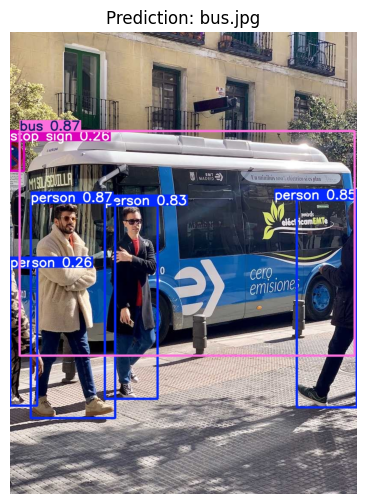

In [ ]:

# This cell shows how to display one saved prediction.
# Update the path below if needed after running prediction.
example_out = Path('runs/detect')  # root directory of predictions
if example_out.exists():
    # Find the newest 'predict*' folder
    latest = sorted(example_out.glob('predict*'))[-1]
    # Find first image file inside
    img_files = list(latest.glob('*.jpg')) + list(latest.glob('*.png'))
    if img_files:
        img_path = str(img_files[0])
        img = cv2.imread(img_path)
        if img is not None:
            # Convert BGR->RGB for notebook display
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(8,6))
            plt.imshow(img_rgb)
            plt.axis('off')
            plt.title(f"Prediction: {Path(img_path).name}")
        else:
            print("Could not read the image. Try another file.")
    else:
        print("No prediction images found yet. Run the predict cell first.")
else:
    print("'runs/detect' not found. Run the predict cell first.")



## 5. Real‑Time / Webcam Inference
> Works best on your laptop/desktop with a webcam. Might not work in some notebook environments.


In [ ]:

# Press 'q' in the window to quit the webcam loop.

def run_webcam_demo(model_path='yolov8n.pt', cam_index=0, conf=0.25):
    if not ULTRALYTICS_AVAILABLE:
        raise RuntimeError("Ultralytics not available.")
    model = YOLO(model_path)
    cap = cv2.VideoCapture(cam_index)

    if not cap.isOpened():
        print("Could not open webcam. Try a different index or ensure a camera is available.")
        return

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # YOLO expects RGB; OpenCV gives BGR
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Run inference (stream=True yields generator of results per frame)
            results = model.predict(source=rgb, conf=conf, verbose=False)

            # Ultralytics returns annotated frames in results[0].plot() (BGR image)
            annotated = results[0].plot()  # returns a NumPy BGR image

            # Show in a window
            cv2.imshow("YOLOv8 Webcam", annotated)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    finally:
        cap.release()
        cv2.destroyAllWindows()

# Example usage (uncomment to run on a local machine with a webcam):
run_webcam_demo(cam_index=0, conf=0.35)


Could not open webcam. Try a different index or ensure a camera is available.



## 6. Fine‑Tune (Transfer Learning) on a Small Dataset
We will **transfer learn** from a pretrained YOLO model using **COCO128** (a small subset of COCO suitable for demos).

- Connects to **Practical 4** (Transfer Learning) and **Practical 15** (Freeze vs. Fine-tune).
- We'll train only a few epochs to keep it quick.


In [ ]:

if not ULTRALYTICS_AVAILABLE:
    raise SystemExit("Please install ultralytics to continue.")

# Tip: choose a model size based on your hardware (n, s, m, l, x).
model = YOLO('yolov8n.pt')  # Nano: fastest, smallest

# Training arguments (adjust as needed)
train_args = dict(
    data='coco128.yaml',   # Ultralytics will download COCO128 automatically (requires internet)
    epochs=5,              # small number for demo; increase for better results
    imgsz=640,             # input size
    batch=16,              # adjust to fit GPU memory
    lr0=1e-3,              # initial learning rate
    patience=3,            # early stopping patience
    device=0 if torch.cuda.is_available() else 'cpu'
)

# Uncomment to run training (beware: this takes time and resources)
results = model.train(**train_args)

print("Training cell ready.")


Ultralytics 8.3.185  Python-3.11.13 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=3, perspective=0.0, plots=True, pose=12.0, pretrained=True, profi

train: Scanning D:\CV\notebooks\datasets\coco128\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.00.0 ms, read: 30.436.1 MB/s, size: 52.5 KB)


val: Scanning D:\CV\notebooks\datasets\coco128\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]


Plotting labels to runs\detect\train4\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000119, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\detect\train4
Starting training for 5 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

        5/5       3.4G      1.179      1.361      1.229        269        640: 100%|██████████| 8/8 [00:01<00:00,  6.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:00<00:00,  5.43it/s]

                   all        128        929      0.683       0.57      0.649      0.478



5 epochs completed in 0.007 hours.
Optimizer stripped from runs\detect\train4\weights\last.pt, 6.5MB
Optimizer stripped from runs\detect\train4\weights\best.pt, 6.5MB

Validating runs\detect\train4\weights\best.pt...
Ultralytics 8.3.185  Python-3.11.13 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:01<00:00,  2.66it/s]


                   all        128        929      0.684       0.57      0.648      0.477
                person         61        254      0.787      0.668      0.767      0.544
               bicycle          3          6      0.495      0.333      0.327      0.272
                   car         12         46      0.895      0.217      0.288      0.173
            motorcycle          4          5      0.703        0.8      0.898      0.718
              airplane          5          6      0.725      0.833      0.927      0.721
                   bus          5          7      0.648      0.714      0.722      0.658
                 train          3          3       0.56      0.667       0.83      0.731
                 truck          5         12      0.995      0.417      0.504      0.292
                  boat          2          6       0.38      0.213      0.355      0.191
         traffic light          4         14      0.725      0.214      0.206       0.14
             stop sig


## 7. Validation & Metrics (Connects to Practical 6)
After/without training, you can compute metrics on the validation split:

- **Precision/Recall** measure prediction quality per class.
- **mAP@0.5:** mean Average Precision at IoU=0.5.  
- **mAP@0.5:0.95:** averaged across IoU thresholds (0.5 → 0.95 step 0.05), stricter and more informative.


In [ ]:

# Validate the (fine‑tuned or pretrained) model
val_results = model.val(data='coco128.yaml', imgsz=640)

# Expected outputs include:
# - Precision/Recall
# - mAP@0.5 and mAP@0.5:0.95
# - Confusion matrix, PR curves (saved to runs/detect/val/)

print("Validation cell ready.")


Ultralytics 8.3.185  Python-3.11.13 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 406.518.5 MB/s, size: 44.7 KB)


val: Scanning D:\CV\notebooks\datasets\coco128\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:04<00:00,  1.74it/s]


                   all        128        929      0.684      0.566      0.651       0.48
                person         61        254        0.8      0.661      0.768      0.544
               bicycle          3          6      0.496      0.333      0.324       0.27
                   car         12         46      0.911      0.217      0.287      0.179
            motorcycle          4          5      0.703        0.8      0.898      0.718
              airplane          5          6      0.723      0.833      0.927      0.721
                   bus          5          7      0.653      0.714      0.721       0.66
                 train          3          3      0.561      0.667       0.83      0.731
                 truck          5         12      0.995      0.417      0.504      0.292
                  boat          2          6      0.257      0.167      0.419      0.168
         traffic light          4         14       0.73      0.214      0.206       0.14
             stop sig


## 8. Batch Inference on a Folder or Video
You can run detection on **all images** in a directory or on a **video file**:


In [ ]:

# --- Folder of images ---
results = model.predict(source='data/samples', imgsz=640, conf=0.25, save=True)

# --- Video file ---
results = model.predict(source='data/videos/traffic.mp4', imgsz=640, conf=0.25, save=True)

# Outputs (annotated frames or video) will appear in runs/detect/predict*



image 1/10 d:\CV\notebooks\data\samples\00052.jpg: 384x640 16 persons, 2 handbags, 30.4ms
image 2/10 d:\CV\notebooks\data\samples\109.jpg: 384x640 1 person, 6 cars, 1 motorcycle, 26.5ms
image 3/10 d:\CV\notebooks\data\samples\1359.jpg: 384x640 5 persons, 1 handbag, 26.5ms
image 4/10 d:\CV\notebooks\data\samples\1452.jpg: 384x640 9 persons, 1 train, 2 handbags, 1 suitcase, 1 frisbee, 24.3ms
image 5/10 d:\CV\notebooks\data\samples\car_data_1_198.jpg: 384x640 4 persons, 3 bicycles, 20 cars, 1 bus, 24.6ms
image 6/10 d:\CV\notebooks\data\samples\car_data_1_3641.jpg: 384x640 19 cars, 1 traffic light, 1 stop sign, 24.3ms
image 7/10 d:\CV\notebooks\data\samples\car_data_1_4420.jpg: 384x640 3 persons, 6 cars, 1 bus, 24.7ms
image 8/10 d:\CV\notebooks\data\samples\car_data_1_4648.jpg: 384x640 1 person, 9 cars, 2 buss, 22.6ms
image 9/10 d:\CV\notebooks\data\samples\car_data_1_8511.jpg: 384x640 21 cars, 1 truck, 21.9ms
image 10/10 d:\CV\notebooks\data\samples\car_data_1_987.jpg: 384x640 6 persons,


## 9. Tips & Troubleshooting
- **GPU recommended** for training; CPU is okay for small demos but slower.
- If memory errors, reduce `imgsz` (e.g., 512 → 416) or `batch` size.
- Start with `yolov8n.pt` (nano). Scale up later (`s`, `m`, `l`, `x`) if you need accuracy and have compute.
- For **your own dataset**, prepare YOLO‑format labels and a `data.yaml` with train/val paths and class names.
- Use **conf** (confidence threshold) and **iou** (NMS IoU threshold) to tune detection results.
- Revisit **Practical 6 (Evaluation Metrics)** for interpreting PR curves and mAP.



## 10. Mini‑Exercises (for understanding)
1. Change `imgsz` (e.g., 320 vs. 640) and compare speed/accuracy. What do you observe?
2. Increase `epochs` to 20 (if GPU available). How do mAP and loss curves change?
3. Try `yolov8s.pt` vs. `yolov8n.pt`. Which is faster? Which performs better?
4. Capture/label 20–50 images of a **custom object** (e.g., bottle, cup), fine‑tune, and test on a video.
5. Export to ONNX and try loading it in an ONNX runtime script (optional advanced).



## Appendix: Boxes, IoU, and NMS (Recap)
- **Bounding Box**: `(x, y, w, h)` or corners `(x1, y1, x2, y2)` in image coordinates.
- **IoU (Intersection over Union)**: `IoU = area(Intersect) / area(Union)` → used to measure overlap.  
- **NMS**: Keeps the highest-confidence box and removes overlapping boxes above an IoU threshold.
- **Anchor‑free heads (YOLOv8)**: Predict centers/offsets directly, simplifying training and improving generalization.



---

### What’s Next?
In **Practical 19**, we’ll build on YOLO by adding **Object Tracking & Counting** in videos (e.g., multi‑object trackers, line‑crossing counts, and simple analytics dashboards). Stay tuned!


---
📝 This practical was designed to gives you a concise, hands-on introduction to **YOLO** (You Only Look Once) for real-time object detection: you’ll run a pretrained **YOLOv8** on images, folders, and webcam/video.